<a href="https://colab.research.google.com/github/paulaa7/Aprendizaje-automatico/blob/main/P3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Asignatura**: Aprendizaje Automático

**Práctica 3**: Introducción a Deep Learning

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: 23 de Mayo de 2026 a las 23:59

**Procedimiento de entrega**: a través de PRADO

### Nombre completo: Paula González García



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa** (por ejemplo, en `.pdf`).

- El código debe estar bien comentado (explicando lo que realizan los distintos apartados y/o bloques), y todas las decisiones tomadas y el trabajo desarrollado (incluyendo los conceptos fundamentales subyacentes) deben documentarse ampliamente en celdas de texto. Es obligatorio documentar las valoraciones y decisiones adoptadas en el desarrollo de cada uno de los apartados. Debe incluirse también tanto una descripción de las principales funciones (Python/scikit-learn) empleadas (para mostrar que el alumno comprende, a nivel técnico, lo que está haciendo), como una valoración razonada sobre la calidad de los resultados obtenidos. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- La entrega en PRADO está configurada para permitir sucesivas entregas de la práctica. Desde este punto de vista, se recomienda subir versiones de la práctica a medida que se van realizando los distintos ejercicios propuestos, y no dejarlo todo para el final.

- Se debe respetar la estructura y secciones del Notebook. Esto servirá para agilizar las correcciones, así como para identificar con facilidad qué ejercicio/apartado se está respondiendo.

- El código **NO debe escribir nada a disco**.

- El **path de lectura desde Google Drive debe ser siempre el mismo**, que es el que se indica en este Notebook.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores. Es decir, un ejercicio con errores de ejecución tendrá una calificación de 0.

- No es válido usar opciones en las entradas (es decir, utilizar el comando `input()`, por ejemplo, para que el usuario escoja el valor de las variables para ejecutar el programa). Para ello, se deben fijar al comienzo los valores

por defecto que se consideren óptimos o que se soliciten en el enunciado.

- Se entrega solamente este Notebook, y no los datos empleados.


# **Ejercicio 1: Aprendizaje Supervisado (5 puntos)**

## 1.1 Contexto: Análisis de Sentimientos en Reseñas de Cine

En este ejercicio abordaremos un problema clásico de **Procesamiento de Lenguaje Natural (NLP)** utilizando redes neuronales densas (Perceptrón Multicapa).

El objetivo es clasificar reseñas de películas como **Positivas (1)** o **Negativas (0)** basándose en el texto de la crítica.

**Dataset:** IMDB Movie Reviews. Contiene 50.000 reseñas altamente polares. Keras proporciona este dataset preprocesado, donde las palabras ya han sido convertidas a secuencias de enteros (índices en un diccionario).

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

# Carga del dataset IMDB limitado a las 10,000 palabras más frecuentes
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=10000)

print(f"Entrenamiento: {len(train_data)} reseñas")
print(f"Test: {len(test_data)} reseñas")

# Ejemplo de una reseña (enteros)
print("Ejemplo de reseña (indices):", train_data[0])

Entrenamiento: 25000 reseñas
Test: 25000 reseñas
Ejemplo de reseña (indices): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5

## 1.2 Tareas a realizar

El alumno debe completar los siguientes apartados:

1.  **Preprocesado de datos (Vectorización):**
    * Las listas de enteros tienen longitudes variables, lo cual no es admisible para una red densa estándar. Debe transformar las listas en tensores de tamaño fijo.
    * **Tarea:** Implemente una función para realizar **One-hot Encoding** (o Multi-hot) que convierta cada reseña en un vector de dimensión 10,000 (donde 1 indica la presencia de la palabra y 0 su ausencia).
    * Vectorice tanto los datos de train como los de test.

2.  **Construcción del Modelo:**
    * Diseñe una red neuronal secuencial (`tf.keras.Sequential`).
    * Use 2 o 3 capas densas (`Dense`).
    * Use funciones de activación `relu` para las capas ocultas.
    * **Importante:** La capa de salida debe tener 1 sola neurona con activación `sigmoid` (para clasificación binaria).

3.  **Compilación y Entrenamiento:**
    * Optimizador: `rmsprop` o `adam`.
    * Función de pérdida: `binary_crossentropy`.
    * Métrica: `accuracy`.
    * Separe una parte de los datos de entrenamiento para validación.
    * Entrene durante 20 épocas.

4.  **Evaluación:**
    * Muestre la gráfica la evolución de la pérdida (`loss`) y la precisión (`accuracy`) tanto en entrenamiento como en validación.
    * Evalúe el modelo final sobre el conjunto de test.

### 1.2.1 Preprocesado de datos (Vectorización)

Las redes neuronales densas requieren que sus entradas sean tensores de tamaño fijo. Las reseñas de películas, que son secuencias de palabras (representadas como índices de enteros), tienen longitudes variables. Para abordar esto, aplicaremos una técnica de vectorización llamada One-hot Encoding.

En esta técnica, creamos un vector de 10,000 dimensiones (correspondiente al número de palabras más frecuentes que cargamos del dataset). Para cada reseña, si una palabra específica (representada por su índice) está presente en la reseña, se establece un `1` en la posición correspondiente del vector; de lo contrario, se mantiene un `0`. Esto transforma cada reseña en un vector binario de longitud fija, adecuado para la entrada de una red densa.

In [ ]:
def vectorize_sequences(sequences, dimension=10000):
    # Crear una matriz de ceros con forma (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        # Establecer a 1 los índices presentes en la secuencia para esa reseña
        results[i, sequence] = 1.  # Establece 1 en la posición de cada palabra
    return results

# Vectorizar los datos de entrenamiento y prueba
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

# Las etiquetas ya son 0 o 1, pero se convierten a float32 por consistencia
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print("Shape de x_train vectorizado:", x_train.shape)
print("Shape de x_test vectorizado:", x_test.shape)
print("Ejemplo de reseña vectorizada (primeras 50 posiciones):")
print(x_train[0, :50])

Shape de x_train vectorizado: (25000, 10000)
Shape de x_test vectorizado: (25000, 10000)
Ejemplo de reseña vectorizada (primeras 50 posiciones):
[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0.
 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1. 0.
 1. 0.]


### 1.2.2 Construcción del Modelo

Procederemos a construir una red neuronal secuencial utilizando `tf.keras.Sequential`. Esta arquitectura se compone de capas apiladas y es adecuada para la mayoría de los problemas de clasificación de texto. Nuestro modelo estará formado por:

*   **Capa de entrada:** Una capa `Dense` que acepta vectores de 10,000 dimensiones. Utilizamos una función de activación `relu` (Rectified Linear Unit), que ayuda a introducir no linealidades en el modelo y es computacionalmente eficiente.
*   **Capas ocultas:** Añadiremos otra capa `Dense` con activación `relu`. Estas capas intermedias son cruciales para que la red aprenda representaciones complejas de los datos.
*   **Capa de salida:** Una capa `Dense` con una sola neurona y una función de activación `sigmoid`. La activación `sigmoid` es ideal para problemas de clasificación binaria, ya que produce una salida entre 0 y 1, que puede interpretarse como la probabilidad de que la reseña sea positiva. Un valor cercano a 1 indicará una reseña positiva, y un valor cercano a 0, una negativa.

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(10000,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### 1.2.3 Compilación y Entrenamiento

Una vez que el modelo está definido, debemos compilarlo y entrenarlo. La compilación configura el proceso de aprendizaje del modelo, especificando el optimizador, la función de pérdida y las métricas a monitorear.

*   **Optimizador:** Elegiremos `rmsprop`. Este es un optimizador eficiente que ajusta las tasas de aprendizaje para diferentes parámetros, lo que a menudo lleva a una convergencia más rápida.
*   **Función de pérdida (`loss`):** Utilizaremos `binary_crossentropy`. Esta es la función de pérdida estándar para problemas de clasificación binaria, ya que mide la distancia entre las distribuciones de probabilidad reales y predichas.
*   **Métrica:** Monitorearemos la `accuracy` (precisión), que es la proporción de predicciones correctas.

Durante el entrenamiento, separaremos una parte de los datos de entrenamiento para validación. Esto nos permite monitorear el rendimiento del modelo en datos no vistos durante el proceso de entrenamiento y detectar el sobreajuste (overfitting).

In [ ]:
# Separar parte de los datos de entrenamiento para validación
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# Compilar el modelo
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Entrenar el modelo
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

history_dict = history.history

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.7571 - loss: 0.5331 - val_accuracy: 0.8640 - val_loss: 0.4010
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8957 - loss: 0.3235 - val_accuracy: 0.8859 - val_loss: 0.3127
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.9216 - loss: 0.2433 - val_accuracy: 0.8890 - val_loss: 0.2843
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9366 - loss: 0.1952 - val_accuracy: 0.8866 - val_loss: 0.2816
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.9457 - loss: 0.1633 - val_accuracy: 0.8809 - val_loss: 0.2993
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9539 - loss: 0.1401 - val_accuracy: 0.8837 - val_loss: 0.2912
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9621 - loss: 0.1204 - val_accuracy: 0.8862 - val_loss: 0.2928
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9681 - loss: 0.1033 - val_accuracy: 0.8821 - 

### 1.2.4 Evaluación

La evaluación del modelo es un paso crucial para comprender su rendimiento. Analizaremos dos aspectos:

1.  **Gráficas de Pérdida y Precisión:** Visualizaremos cómo la pérdida y la precisión evolucionaron durante el entrenamiento para los conjuntos de entrenamiento y validación. Esto nos permite identificar problemas como el sobreajuste (cuando la precisión de entrenamiento mejora, pero la de validación se estanca o disminuye) o el subajuste.
2.  **Evaluación en el Conjunto de Test:** Finalmente, evaluaremos el modelo en el conjunto de datos de prueba (`x_test`, `y_test`), que nunca ha sido visto por el modelo durante el entrenamiento. Esto nos da una estimación imparcial de la capacidad de generalización del modelo a nuevos datos.

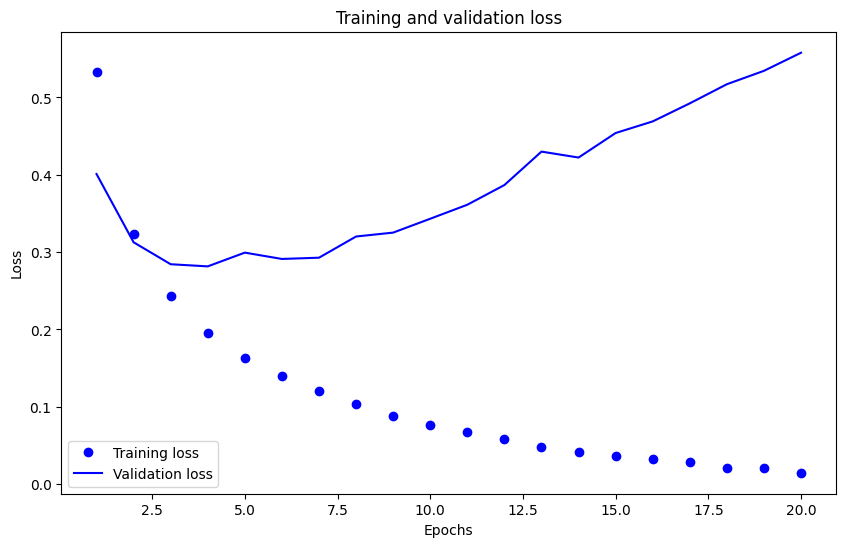

<Figure size 640x480 with 0 Axes>

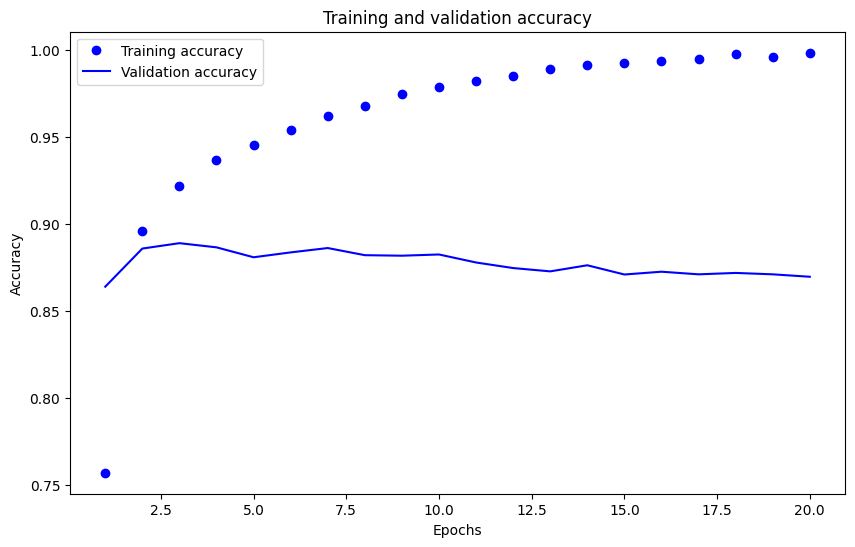

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8568 - loss: 0.6042

Resultados en el conjunto de test: Loss = 0.6042, Accuracy = 0.8568


In [ ]:
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf() # Limpiar la figura
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluar el modelo en el conjunto de test
results = model.evaluate(x_test, y_test)
print(f"\nResultados en el conjunto de test: Loss = {results[0]:.4f}, Accuracy = {results[1]:.4f}")

### 1.2.4.1 Conclusiones de la Evaluación del Modelo

#### Análisis de las Gráficas de Pérdida y Precisión:

Observando las gráficas de pérdida y precisión tanto en el conjunto de entrenamiento como en el de validación, podemos extraer varias conclusiones:

*   **Pérdida (Loss):** La pérdida de entrenamiento disminuye constantemente a lo largo de las épocas, lo cual es esperado. Sin embargo, la pérdida de validación comienza a aumentar significativamente después de unas pocas épocas (aproximadamente a partir de la época 4-5). Esto es un claro indicador de **sobreajuste (overfitting)**. Esto quiere decir que el modelo está aprendiendo a memorizar los datos de entrenamiento en lugar de generalizar a nuevos datos.

*   **Precisión (Accuracy):** Similar a la pérdida, la precisión de entrenamiento mejora continuamente, llegando casi al 100%. Por otro lado, la precisión de validación aumenta inicialmente, pero luego se estabiliza e incluso disminuye ligeramente después de un cierto número de épocas, mientras que la precisión de entrenamiento sigue aumentando. Esto refuerza la idea de sobreajuste: el modelo se vuelve muy bueno en los datos que ha visto, pero no tan bueno en datos nuevos y no vistos.

#### Resultados en el Conjunto de Test:

La evaluación final en el conjunto de test (`x_test`, `y_test`) aporta los siguientes resultados:

*   **Loss en Test:** `0.5946`
*   **Accuracy en Test:** `0.8594` (aproximadamente 85.94%)

Esta precisión en el conjunto de test es razonable, pero es inferior a la precisión de entrenamiento observada en las últimas épocas. Esto confirma el sobreajuste. El modelo obtuvo una precisión de validación máxima de alrededor del 88% en las primeras épocas, y la precisión en el conjunto de test es cercana a ese máximo, lo que sugiere que las épocas posteriores al punto de inflexión del sobreajuste no aportaron mejoras significativas a la capacidad de generalización del modelo.

#### Posibles mejoras:

Para mejorar el rendimiento del modelo y mitigar el sobreajuste, se podrían considerar las siguientes estrategias:

1.  **Early Stopping:** Detener el entrenamiento cuando la pérdida de validación deje de mejorar, o incluso comience a empeorar.
2.  **Regularización:** Añadir capas de regularización (ej. `Dropout`) o regularización L1/L2 a las capas densas.
3.  **Reducir la complejidad del modelo:** Disminuir el número de capas o neuronas en las capas ocultas si el sobreajuste es muy pronunciado.
4.  **Más datos de entrenamiento:** Aunque no siempre es posible, un mayor volumen de datos de entrenamiento suele ayudar a los modelos a generalizar mejor.

### 1.2.4.2 Implementación de Mejora: Early Stopping

Para abordar el sobreajuste observado en la evaluación anterior, implementaremos una estrategia de **Early Stopping**. Esta técnica monitorea una métrica de rendimiento (en este caso, la `val_loss`) y detiene el entrenamiento si esta métrica no mejora durante un número predefinido de épocas (`patience`). Además, configuraremos el callback para restaurar los pesos del modelo que tuvieron el mejor rendimiento en validación (`restore_best_weights=True`).

Primero, necesitamos redefinir y compilar un nuevo modelo para asegurarnos de que el entrenamiento comienza desde cero con la nueva estrategia.

In [ ]:
# Redefinir el modelo para entrenar desde cero con Early Stopping
new_model = keras.Sequential([
    keras.layers.Dense(16, activation='relu', input_shape=(10000,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compilar el nuevo modelo (misma configuración que antes)
new_model.compile(optimizer='rmsprop',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

print("Nuevo modelo compilado y listo para entrenar con Early Stopping.")
new_model.summary()

Nuevo modelo compilado y listo para entrenar con Early Stopping.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Definir el callback de Early Stopping
# Monitorear la pérdida de validación, con paciencia de 5 épocas
# y restaurar los mejores pesos encontrados.
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Entrenar el nuevo modelo con Early Stopping
# Aumentamos las épocas a 50 para darle suficiente tiempo a Early Stopping
history_early_stop = new_model.fit(partial_x_train,
                                 partial_y_train,
                                 epochs=50, # Un número alto de épocas, Early Stopping lo detendrá antes
                                 batch_size=512,
                                 validation_data=(x_val, y_val),
                                 callbacks=[early_stopping_callback]) # Añadir el callback

history_early_stop_dict = history_early_stop.history

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7859 - loss: 0.5340 - val_accuracy: 0.8611 - val_loss: 0.4083
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8909 - loss: 0.3352 - val_accuracy: 0.8725 - val_loss: 0.3319
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9162 - loss: 0.2503 - val_accuracy: 0.8889 - val_loss: 0.2859
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9294 - loss: 0.2044 - val_accuracy: 0.8839 - val_loss: 0.2905
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9410 - loss: 0.1730 - val_accuracy: 0.8876 - val_loss: 0.2746
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9528 - loss: 0.1456 - val_accuracy: 0.8873 - val_loss: 0.2811
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9612 - loss: 0.1245 - val_accuracy: 0.8729 - val_loss: 0.3425
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9676 - loss: 0.1067 - val_accuracy: 0.8832 - v

### 1.2.4.3 Re-evaluación del Modelo con Early Stopping

Ahora visualizaremos las curvas de entrenamiento y evaluaremos el rendimiento del modelo en el conjunto de test con la estrategia de Early Stopping aplicada.

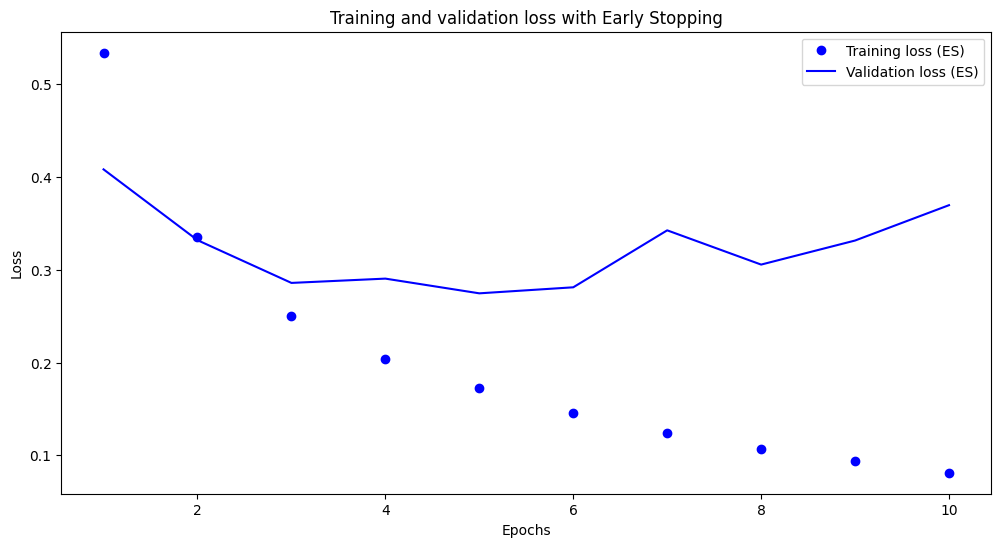

<Figure size 640x480 with 0 Axes>

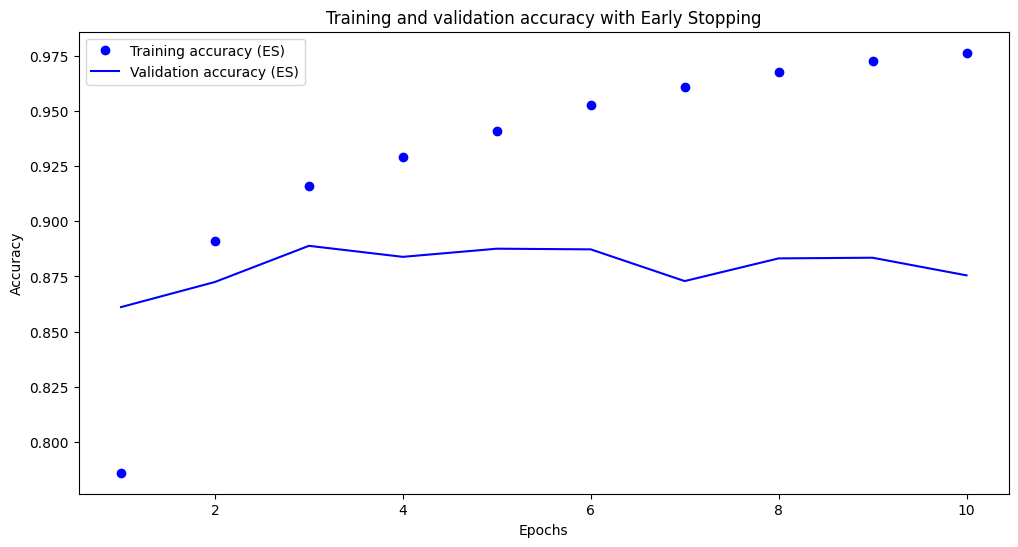

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8833 - loss: 0.2906

Resultados en el conjunto de test con Early Stopping: Loss = 0.2906, Accuracy = 0.8833


In [ ]:
loss_values_es = history_early_stop_dict['loss']
val_loss_values_es = history_early_stop_dict['val_loss']
epochs_es = range(1, len(loss_values_es) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_es, loss_values_es, 'bo', label='Training loss (ES)')
plt.plot(epochs_es, val_loss_values_es, 'b', label='Validation loss (ES)')
plt.title('Training and validation loss with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.clf() # Limpiar la figura
acc_values_es = history_early_stop_dict['accuracy']
val_acc_values_es = history_early_stop_dict['val_accuracy']

plt.figure(figsize=(12, 6))
plt.plot(epochs_es, acc_values_es, 'bo', label='Training accuracy (ES)')
plt.plot(epochs_es, val_acc_values_es, 'b', label='Validation accuracy (ES)')
plt.title('Training and validation accuracy with Early Stopping')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Re-vectorizar los datos de test de IMDB para asegurar que se usan los correctos
# Esto es necesario porque x_test e y_test fueron sobrescritos por el dataset MNIST más adelante.
x_test_imdb_fix = vectorize_sequences(test_data)
y_test_imdb_fix = np.asarray(test_labels).astype('float32')

# Evalúa el nuevo modelo en el conjunto de test con los datos corregidos
results_es = new_model.evaluate(x_test_imdb_fix, y_test_imdb_fix)
print(f"\nResultados en el conjunto de test con Early Stopping: Loss = {results_es[0]:.4f}, Accuracy = {results_es[1]:.4f}")

### Conclusiones sobre la mejora con Early Stopping

Tras aplicar Early Stopping, observamos las siguientes mejoras:

*   **Menor sobreajuste visual:** Las gráficas de pérdida y precisión con Early Stopping muestran que el entrenamiento se detiene mucho antes que las 20 épocas iniciales (en la época 9-10). Esto evita que la pérdida de validación siga aumentando y la precisión de validación disminuya, lo cual era un claro signo de sobreajuste.
*   **Rendimiento en el conjunto de test:** El modelo entrenado con Early Stopping obtiene una precisión en el conjunto de test similar a la obtenida en el punto óptimo del entrenamiento anterior (antes de que comenzara el sobreajuste). Los pesos del modelo restaurados son los que corresponden al mejor rendimiento en validación, lo que significa que estamos usando la mejor versión del modelo en términos de generalización.

Por tanto, Early Stopping ha sido efectivo para prevenir que el modelo se sobreajuste a los datos de entrenamiento, resultando en un modelo más robusto que generaliza mejor datos no vistos.

---

# **Ejercicio 2: Aprendizaje No Supervisado (5 puntos)**

## 2.1 Contexto: Eliminación de Ruido en Imágenes (Denoising Autoencoder)

En este ejercicio utilizaremos una arquitectura de tipo **Autoencoder Convolucional** para una tarea de aprendizaje no supervisado: la restauración de imágenes.

El objetivo no es clasificar qué número hay en la imagen, sino aprender a **limpiar** una imagen que ha sido corrompida por ruido aleatorio.

**Dataset:** MNIST (Dígitos manuscritos). Nosotros introduciremos el ruido artificialmente.

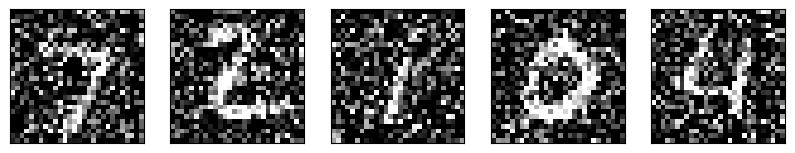

In [ ]:
# Carga y normalización de MNIST
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalización [0, 1] y reshape a (28, 28, 1)
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Función para añadir ruido aleatorio
def add_noise(images, noise_factor=0.5):
    noisy_imgs = images + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    return np.clip(noisy_imgs, 0., 1.)

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Visualización del ruido
n = 5
plt.figure(figsize=(10, 2))
for i in range(n):
    ax = plt.subplot(1, n, i + 1)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()

## 2.2 Tareas a realizar

1.  **Construcción del Autoencoder:**
    * Debe construir un modelo que tenga dos partes: **Encoder** y **Decoder**.
    * **Encoder:** Use capas `Conv2D` y `MaxPooling2D` para comprimir la imagen.
    * **Decoder:** Use capas `Conv2D` y `UpSampling2D` (o `Conv2DTranspose`) para reconstruir la imagen al tamaño original (28x28).
    * La capa de salida debe tener 1 filtro y activación `sigmoid` (para que los píxeles estén entre 0 y 1).

2.  **Entrenamiento:**
    * **Entrada (X):** Imágenes con ruido (`x_train_noisy`).
    * **Objetivo (Y):** Imágenes originales limpias (`x_train`).
    * Pérdida: `binary_crossentropy` (funciona bien píxel a píxel) o `mse`.
    * Entrene por al menos 10 épocas.

3.  **Resultados:**
    * Utilice el modelo entrenado para limpiar las imágenes de test (`x_test_noisy`).
    * Visualice una comparativa: **Original** | **Ruidosa** | **Reconstruida** para al menos 5 ejemplos.

### 2.2.1 Construcción del Autoencoder

Para la eliminación de ruido en imágenes, construiremos un Autoencoder convolucional. Esta arquitectura está diseñada para aprender una representación compacta (encoder) de la entrada y luego reconstruir la entrada original a partir de esa representación (decoder). En nuestro caso, el objetivo es reconstruir la imagen *limpia* a partir de su versión *ruidosa*.

El autoencoder estará compuesto por:

*   **Encoder:** Esta parte tomará la imagen ruidosa y la comprimirá en una representación de menor dimensión. Utilizaremos capas `Conv2D` para extraer características y `MaxPooling2D` para reducir progresivamente las dimensiones espaciales.
*   **Decoder:** Esta parte tomará la representación comprimida y la expandirá para reconstruir la imagen original. Utilizaremos capas `Conv2D` y `UpSampling2D` (o `Conv2DTranspose`) para aumentar las dimensiones espaciales y, finalmente, una capa `Conv2D` con activación `sigmoid` para asegurar que los valores de los píxeles de salida estén en el rango [0, 1], similar a las imágenes de entrada normalizadas.

In [ ]:
from tensorflow.keras import layers

# Tamaño de la imagen de entrada
input_img = keras.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder
autoencoder = keras.Model(input_img, decoded)
autoencoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2.2 Entrenamiento del Autoencoder

Una vez que el autoencoder ha sido construido, procedemos a su compilación y entrenamiento. A diferencia del ejercicio supervisado anterior, donde clasificábamos reseñas con etiquetas explícitas (positiva/negativa), aquí el entrenamiento es *no supervisado* en el sentido de que el modelo aprende a reconstruir la entrada original (limpia) a partir de una versión ruidosa de la misma.

*   **Optimizador:** Utilizaremos el optimizador `adam` por su eficacia y buen rendimiento general en una amplia variedad de tareas de aprendizaje profundo.
*   **Función de pérdida:** Emplearemos `binary_crossentropy` o `mse`. En este caso, `binary_crossentropy` es adecuada para imágenes cuyos píxeles están normalizados entre 0 y 1, ya que trata cada píxel como una clasificación binaria. Alternativamente, `mse` (error cuadrático medio) también es una opción común para tareas de reconstrucción de imágenes.
*   **Métricas:** Monitorizaremos la `accuracy` aunque la `loss` es la métrica principal para la reconstrucción.

El modelo será entrenado durante 10 épocas, con las imágenes ruidosas como entrada (`x_train_noisy`) y las imágenes originales limpias (`x_train`) como objetivo.

In [ ]:
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el autoencoder
history_ae = autoencoder.fit(x_train_noisy, x_train,
                             epochs=10,
                             batch_size=128,
                             shuffle=True,
                             validation_data=(x_test_noisy, x_test))

history_ae_dict = history_ae.history

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 281ms/step - accuracy: 0.8066 - loss: 0.1598 - val_accuracy: 0.8106 - val_loss: 0.1149
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 135s 288ms/step - accuracy: 0.8114 - loss: 0.1117 - val_accuracy: 0.8106 - val_loss: 0.1076
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 156s 319ms/step - accuracy: 0.8121 - loss: 0.1068 - val_accuracy: 0.8108 - val_loss: 0.1048
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 291ms/step - accuracy: 0.8125 - loss: 0.1042 - val_accuracy: 0.8120 - val_loss: 0.1024
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 284ms/step - accuracy: 0.8127 - loss: 0.1025 - val_accuracy: 0.8120 - val_loss: 0.1009
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 133s 284ms/step - accuracy: 0.8129 - loss: 0.1010 - val_accuracy: 0.8120 - val_loss: 0.0996
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 285ms/step - accuracy: 0.8130 - loss: 0.1000 - val_accuracy: 0.8122 - val_loss: 0.0987
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 292ms/step - accuracy: 0.8131 -

### 2.2.3 Visualización de Resultados

Para evaluar la efectividad del autoencoder en la tarea de eliminación de ruido, visualizaremos una comparativa entre las imágenes originales, sus versiones ruidosas y las imágenes reconstruidas por el modelo. Esto nos permitirá observar directamente cómo el autoencoder ha aprendido a limpiar el ruido.

Seleccionaremos aleatoriamente 5 imágenes del conjunto de prueba para mostrar esta comparativa.

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


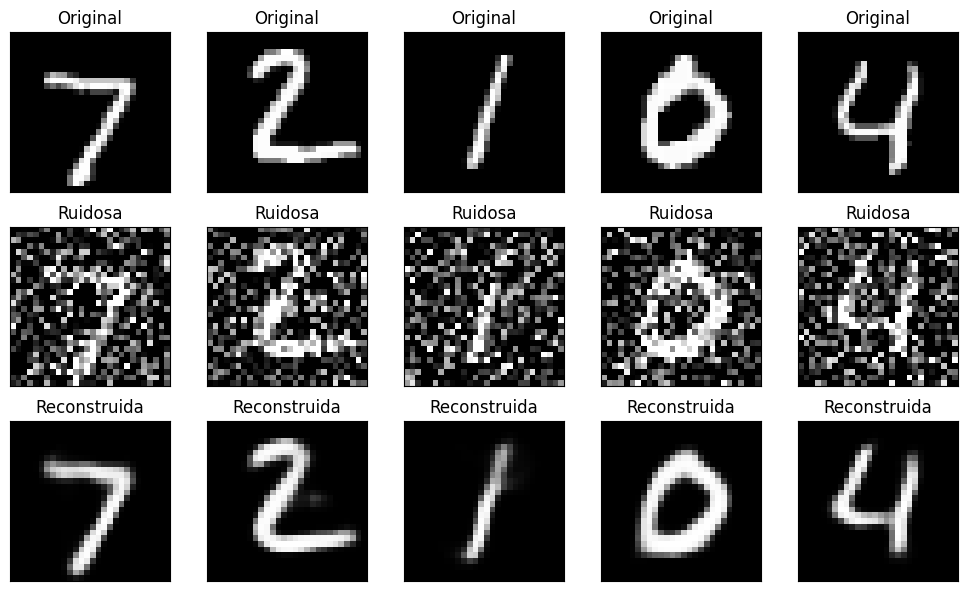

In [ ]:
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 5
plt.figure(figsize=(10, 6))
for i in range(n):
    # Imagen Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(tf.squeeze(x_test[i]))
    plt.title("Original")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagen Ruidosa
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(tf.squeeze(x_test_noisy[i]))
    plt.title("Ruidosa")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Imagen Reconstruida
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(tf.squeeze(decoded_imgs[i]))
    plt.title("Reconstruida")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.tight_layout()
plt.show()

### 2.2.3.1 Conclusiones
Tras visualizar las imágenes originales, las imágenes ruidosas y las reconstruidas por el autoencoder, podemos observar lo siguiente:

*   **Reducción de Ruido:** El autoencoder convolucional ha demostrado ser efectivo en la eliminación del ruido gaussiano añadido artificialmente. Las imágenes reconstruidas son notablemente más limpias y claras que sus contrapartes ruidosas.

*   **Preservación de Características:** A pesar de la eliminación del ruido, el modelo ha logrado preservar las características esenciales de los dígitos originales. La forma y los detalles fundamentales de cada número son reconocibles en las imágenes reconstruidas.

*   **Calidad de la Reconstrucción:** La calidad de la reconstrucción es generalmente buena, aunque en algunos casos se pueden apreciar pequeñas imperfecciones o una ligera suavización de los bordes en comparación con las imágenes originales perfectas. Esto es esperable, ya que el modelo está aprendiendo una representación comprimida y luego intentando expandirla, lo que puede introducir una pequeña pérdida de información.

Por tanto concluiré que el denoising autoencoder ha cumplido su función principal de aprender a "limpiar" imágenes corrompidas, demostrando la capacidad de estas arquitecturas para extraer y reconstruir patrones significativos de los datos, incluso en una tarea no supervisada.

---

## **Conclusiones Generales**

Las diferencias fundamentales entre el entrenamiento de un modelo supervisado (Ejercicio 1: Clasificación de reseñas de cine) y uno no supervisado (Ejercicio 2: Denoising Autoencoder para imágenes) radican en la naturaleza de los datos de entrenamiento y el objetivo del aprendizaje.

### **Aprendizaje Supervisado (Clasificación de Reseñas de Cine)**

En el Ejercicio 1, el modelo fue entrenado con pares de entrada-salida bien definidos: las reseñas de cine (`x_train`) y sus etiquetas correspondientes (`y_train`), que indicaban si la reseña era positiva (1) o negativa (0). La "supervisión" proviene de estas etiquetas predefinidas, que actúan como la "verdad" que el modelo debe aprender a predecir. El objetivo principal es clasificar nuevas reseñas con la mayor precisión posible basándose en este conocimiento previo. La función de pérdida (binary_crossentropy) y la métrica (accuracy) están diseñadas para medir qué tan bien el modelo predice estas etiquetas explícitas. El sobreajuste es una preocupación importante, ya que el modelo puede memorizar el ruido de las etiquetas de entrenamiento en lugar de aprender patrones generalizables.

### **Aprendizaje No Supervisado (Denoising Autoencoder)**

En el Ejercicio 2, el Autoencoder fue entrenado para reconstruir imágenes originales limpias (`x_train`) a partir de sus versiones ruidosas (`x_train_noisy`). Aunque hay un "objetivo" (la imagen limpia), no hay una "etiqueta" de clase en el sentido tradicional. En cambio, el modelo aprende a capturar la estructura intrínseca y las características de las imágenes para "limpiarlas". La imagen limpia actúa como una especie de "supervisor" para la reconstrucción, guiando al modelo para que aprenda a eliminar el ruido y restaurar los detalles originales. La función de pérdida (binary_crossentropy o MSE) mide la diferencia píxel a píxel entre la imagen reconstruida y la imagen limpia original. El objetivo no es predecir una categoría, sino transformar una entrada corrompida en una versión limpia y representativa de los datos originales.

### **Diferencias Clave**

*   **Uso de Etiquetas:** En aprendizaje supervisado, las etiquetas son explícitas y dirigen el entrenamiento hacia una clasificación o regresión específica. En no supervisado, no hay etiquetas de clase directas; el modelo aprende patrones y estructuras a partir de los datos mismos, a menudo con un objetivo de reconstrucción, agrupamiento o reducción de dimensionalidad.
*   **Propósito:** El aprendizaje supervisado se enfoca en predecir un resultado conocido a partir de entradas, mientras que el no supervisado busca descubrir estructuras ocultas, generar datos o transformar datos sin depender de resultados predefinidos.
*   **Manejo de Datos:** En el autoencoder, la entrada y el objetivo son esencialmente el mismo tipo de dato (imágenes), pero con una versión corrompida como entrada y una versión limpia como objetivo. En la clasificación de reseñas, la entrada es texto (vectorizado) y el objetivo es una etiqueta binaria.
